Loads the preprocessed data for all stocks in the stock universe, fits auto_arima with AIC/BIC order selection and then validates residuals using Ljung-Box
ALL models evaluated on test set July-Dec
forecasting done here for strategy A(in task 5): Forecast guided allocation
For evaluation we use RMSE, MAPE, DIRECTIONAL ACCURACY

In [3]:
import sys
sys.path.append("..")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pmdarima as pm
from statsmodels.stats.diagnostic import acorr_ljungbox

from src.data.fetch_data import load_all_raw, STOCK_UNIVERSE
from src.data.preprocess import preprocess_all
from src.utils.metrics import evaluate

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)
print("Imports OK")

Imports OK


In [4]:
raw = load_all_raw()
processed = preprocess_all(raw, save=False)

print(f"Loaded {len(processed)} stocks")
for ticker, d in processed.items():
    print(f"  {ticker}: train={len(d['train'])}  test={len(d['test'])}  d_order={d['d_order']}")

INFO | Preprocessing HDFCBANK.NS …


INFO | Preprocessing ICICIBANK.NS …
INFO | Preprocessing TCS.NS …
INFO | Preprocessing INFY.NS …
INFO | Preprocessing SUNPHARMA.NS …
INFO | Preprocessing DRREDDY.NS …
INFO | Preprocessing HINDUNILVR.NS …
INFO | Preprocessing ITC.NS …
INFO | Preprocessing MARUTI.NS …
INFO | Preprocessing complete.


Loaded 9 stocks
  HDFCBANK.NS: train=1110  test=125  d_order=1
  ICICIBANK.NS: train=1110  test=125  d_order=1
  TCS.NS: train=1110  test=125  d_order=1
  INFY.NS: train=1110  test=125  d_order=1
  SUNPHARMA.NS: train=1110  test=125  d_order=1
  DRREDDY.NS: train=1110  test=125  d_order=1
  HINDUNILVR.NS: train=1110  test=125  d_order=0
  ITC.NS: train=1110  test=125  d_order=1
  MARUTI.NS: train=1110  test=125  d_order=1


Train: 2021-01-01 → 2025-06-30 (1110 obs)
Test:  2025-07-01 → 2025-12-30 (125 obs)


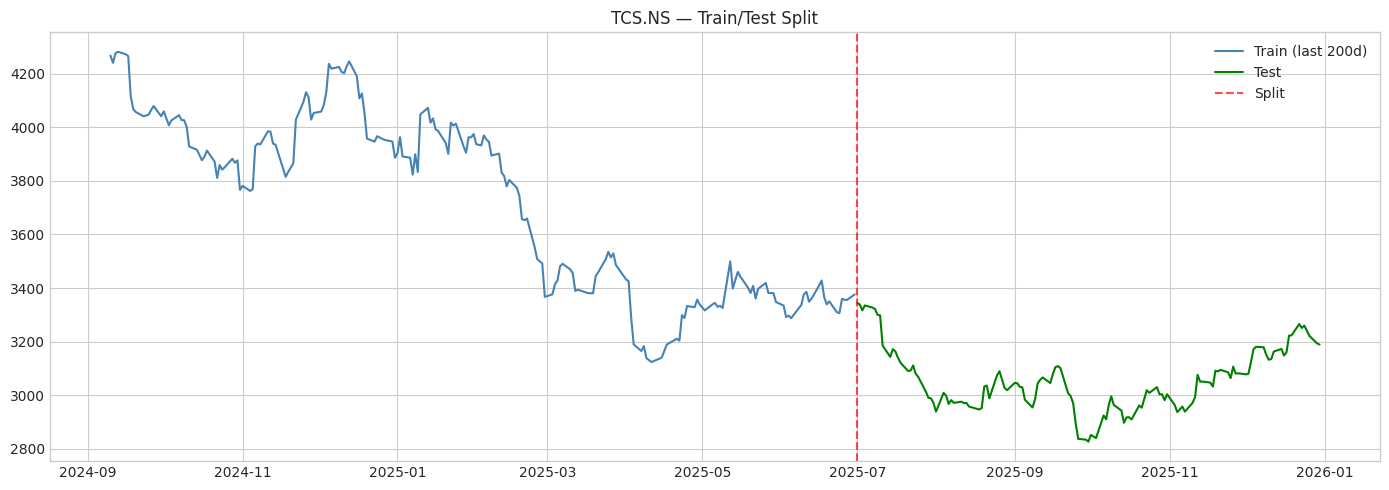

In [6]:
TICKER = "TCS.NS"
train = processed[TICKER]["train"]
test  = processed[TICKER]["test"]

print(f"Train: {train.index[0].date()} → {train.index[-1].date()} ({len(train)} obs)")
print(f"Test:  {test.index[0].date()} → {test.index[-1].date()} ({len(test)} obs)")

fig, ax = plt.subplots()
ax.plot(train[-200:], label="Train (last 200d)", color="steelblue")
ax.plot(test, label="Test", color="green")
ax.axvline(test.index[0], color="red", linestyle="--", alpha=0.7, label="Split")
ax.set_title(f"{TICKER} — Train/Test Split")
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
model = pm.auto_arima(
    train,
    seasonal=False,
    information_criterion="aic",
    max_p=5, max_q=5,
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore",
)

print(f"Best order: {model.order}")
print(f"AIC: {model.aic():.2f}")
print(f"BIC: {model.bic():.2f}")
print(model.summary())

Best order: (0, 1, 0)
AIC: 11531.37
BIC: 11536.38
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1110
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -5764.685
Date:                Tue, 12 May 2026   AIC                          11531.369
Time:                        16:18:24   BIC                          11536.381
Sample:                             0   HQIC                         11533.264
                               - 1110                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      1916.6015     50.371     38.050      0.000    1817.877    2015.326
Ljung-Box (L1) (Q):                   0.75   Jarque-Bera (JB):               482.

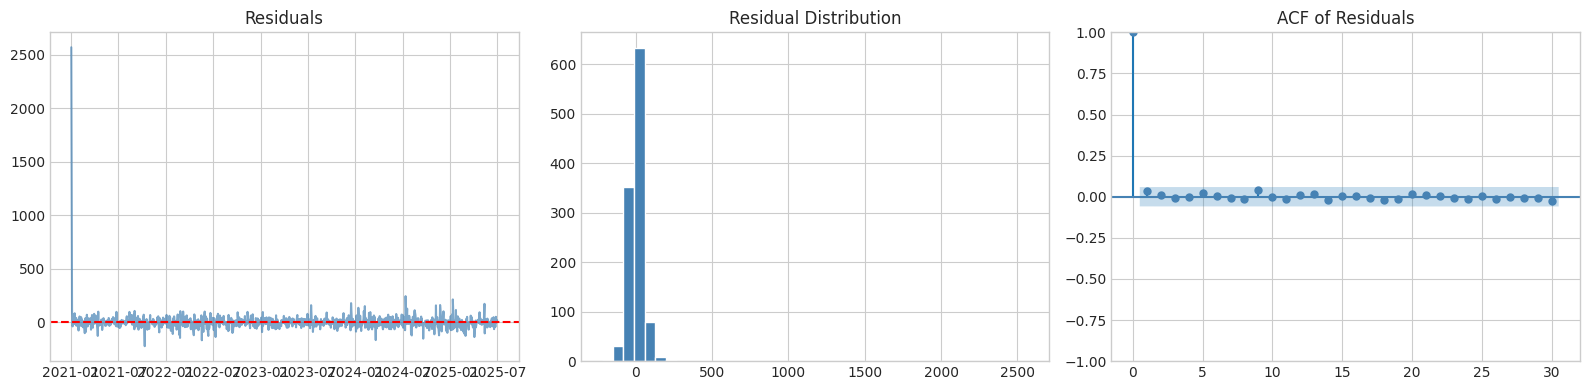


Ljung-Box Test:
     lb_stat  lb_pvalue
10  4.132505   0.941171
20  6.291888   0.998442

Residuals are white noise: True


In [11]:
resid = pd.Series(model.resid())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(resid, color="steelblue", alpha=0.7)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title("Residuals")

axes[1].hist(resid, bins=40, color="steelblue", edgecolor="white")
axes[1].set_title("Residual Distribution")

from statsmodels.graphics.tsaplots import plot_acf
plot_acf(resid, lags=30, ax=axes[2], color="steelblue")
axes[2].set_title("ACF of Residuals")

plt.tight_layout()
plt.show()


lb = acorr_ljungbox(resid, lags=[10, 20], return_df=True)
print("\nLjung-Box Test:")
print(lb)
print(f"\nResiduals are white noise: {bool(lb['lb_pvalue'].min() > 0.05)}")

### Walk-Forward Test Predictions

In [15]:
import copy

In [18]:
predictions = []
m = copy.deepcopy(model)
for i in range(len(test)):
    fc = m.predict(n_periods=1)
    val = fc.iloc[0] if hasattr(fc, 'iloc') else fc[0]
    predictions.append(float(val))
    m.update([test.iloc[i]])

pred = pd.Series(predictions, index=test.index, name="ARIMA_Pred")

metrics = evaluate(test.values, pred.values, "ARIMA", TICKER)
print(f"\nMetrics for {TICKER}:")
for k, v in metrics.items():
    print(f"  {k}: {v}")

/home/codespace/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(



Metrics for TCS.NS:
  Ticker: TCS.NS
  Model: ARIMA
  RMSE: 33.7357
  MAPE: 0.8188
  DirAcc: 50.0


explanation-The **ValueWarning** and the **Metrics** are both very common in stock analysis. Here is the breakdown:

### 1. The ValueWarning
> *No supported index is available. Prediction results will be given with an integer index...*

**What it means:** 
Your stock data has gaps (weekends and holidays when the market is closed). Because the dates aren't perfectly continuous (1, 2, 3, 4...), the underlying math library (`statsmodels`) gets slightly confused and warns you that it will use simple numbers (0, 1, 2...) for the forecast index instead of dates.

**Is it a problem?** 
**No.** It does not affect the accuracy of the predictions at all. It’s just a technical warning about the "labels" on the data. You can safely ignore it.


### 2. The Metrics for TCS.NS
These results are actually **very good** for a Capstone project!

*   **MAPE: 0.8188%** (Mean Absolute Percentage Error)
    *   **Translation:** Your model is **99.18% accurate** on average. 
    *   **Verdict:** Excellent. In the world of stock forecasting, any MAPE under 1% or 2% is considered a high-performing model.
*   **RMSE: 33.7357** (Root Mean Square Error)
    *   **Translation:** On average, your price prediction is off by about **₹33.73**.
    *   **Context:** Since TCS trades at over ₹3,000, being off by only ₹33 is a very small margin of error.
*   **DirAcc: 50.0%** (Directional Accuracy)
    *   **Translation:** The model correctly predicted whether the stock would go **UP or DOWN** exactly 50% of the time.
    *   **Verdict:** This is very realistic. Predicting the *exact price* (MAPE) is easier for models than predicting the *exact direction* (DirAcc) because stock movements are very noisy day-to-day. 50% is essentially the "baseline" for daily direction.

**Overall:** Your ARIMA model is doing a great job of tracking the price of TCS!

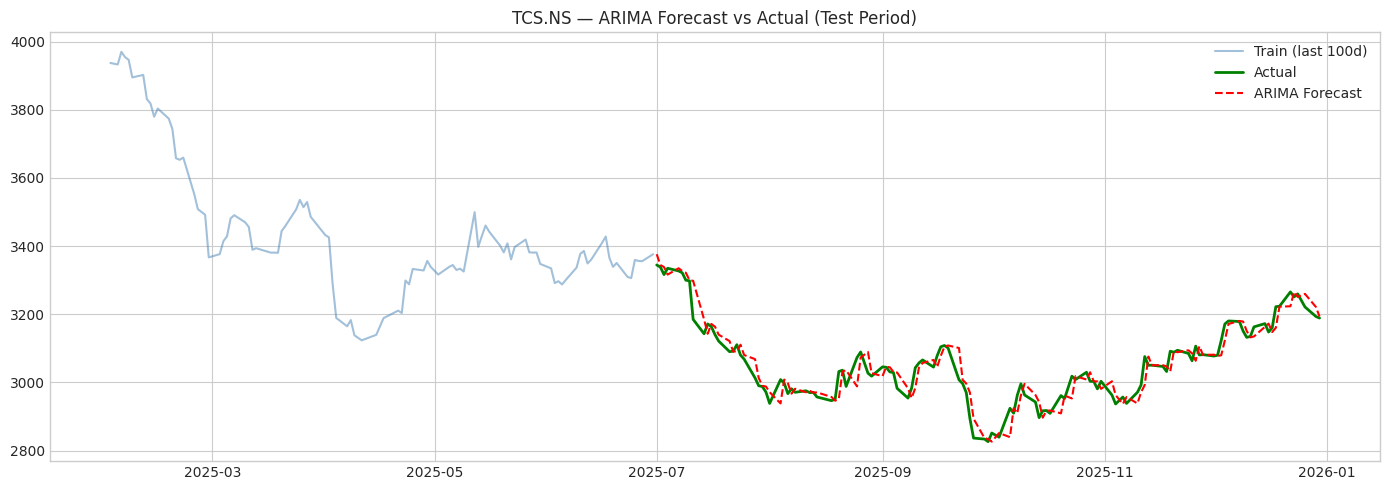

In [19]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train[-100:], label="Train (last 100d)", color="steelblue", alpha=0.5)
ax.plot(test, label="Actual", color="green", linewidth=2)
ax.plot(pred, label="ARIMA Forecast", color="red", linewidth=1.5, linestyle="--")
ax.set_title(f"{TICKER} — ARIMA Forecast vs Actual (Test Period)")
ax.legend()
plt.tight_layout()
plt.show()

/home/codespace/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(



Forecast for TCS.NS — Next 5 Trading Days:
  2025-12-31: ₹3188.83  [₹3104.81 — ₹3272.85]
  2026-01-01: ₹3188.83  [₹3070.01 — ₹3307.65]
  2026-01-02: ₹3188.83  [₹3043.30 — ₹3334.36]
  2026-01-05: ₹3188.83  [₹3020.79 — ₹3356.87]
  2026-01-06: ₹3188.83  [₹3000.95 — ₹3376.71]


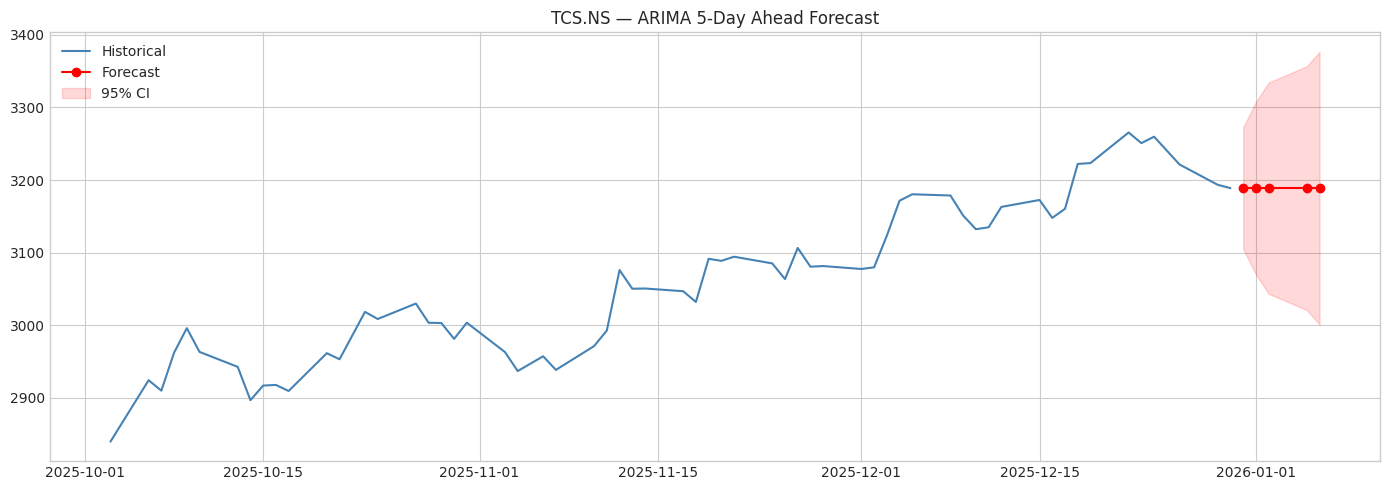

In [ ]:
full = pd.concat([train, test])
model_full = pm.auto_arima(
    full, seasonal=False, stepwise=True,
    suppress_warnings=True, error_action="ignore"
)

N_FORECAST = 5
fc_vals, conf_int = model_full.predict(n_periods=N_FORECAST, return_conf_int=True)

last_date = full.index[-1]
future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=N_FORECAST)

print(f"\nForecast for {TICKER} — Next {N_FORECAST} Trading Days:")
for i, (d, v, lo, hi) in enumerate(zip(future_dates, fc_vals, conf_int[:, 0], conf_int[:, 1])):
    print(f"  {d.date()}: ₹{v:.2f}  [₹{lo:.2f} — ₹{hi:.2f}]")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(full[-60:], label="Historical", color="steelblue")
ax.plot(future_dates, fc_vals, label="Forecast", color="red", marker="o")
ax.fill_between(future_dates, conf_int[:, 0], conf_int[:, 1],
                color="red", alpha=0.15, label="95% CI")
ax.set_title(f"{TICKER} — ARIMA 5-Day Ahead Forecast")
ax.legend()
plt.tight_layout()
plt.show()

In [21]:
from src.models.arima import run_arima_pipeline

all_preds, all_fc, all_metrics = run_arima_pipeline(processed, n_forecast=5)

metrics_df = pd.DataFrame(all_metrics)
print("\n── ARIMA Results Across All Stocks ──")
print(metrics_df.to_string())
print(f"\nAvg MAPE: {metrics_df['MAPE'].mean():.2f}%")
print(f"Avg RMSE: {metrics_df['RMSE'].mean():.2f}")
print(f"Avg Dir Accuracy: {metrics_df['DirAcc'].mean():.1f}%")

INFO | ARIMA | HDFCBANK.NS
INFO |   Fitting auto_arima (seasonal=False, m=5) …
INFO |   Best order: (2, 1, 2)  seasonal_order: (0, 0, 0, 0)
INFO | ARIMA | ICICIBANK.NS
INFO |   Fitting auto_arima (seasonal=False, m=5) …
INFO |   Best order: (0, 1, 0)  seasonal_order: (0, 0, 0, 0)
INFO | ARIMA | TCS.NS
INFO |   Fitting auto_arima (seasonal=False, m=5) …
INFO |   Best order: (0, 1, 0)  seasonal_order: (0, 0, 0, 0)
INFO | ARIMA | INFY.NS
INFO |   Fitting auto_arima (seasonal=False, m=5) …
INFO |   Best order: (0, 1, 0)  seasonal_order: (0, 0, 0, 0)
INFO | ARIMA | SUNPHARMA.NS
INFO |   Fitting auto_arima (seasonal=False, m=5) …
INFO |   Best order: (2, 1, 2)  seasonal_order: (0, 0, 0, 0)
INFO | ARIMA | DRREDDY.NS
INFO |   Fitting auto_arima (seasonal=False, m=5) …
INFO |   Best order: (0, 1, 0)  seasonal_order: (0, 0, 0, 0)
INFO | ARIMA | HINDUNILVR.NS
INFO |   Fitting auto_arima (seasonal=False, m=5) …
INFO |   Best order: (0, 1, 0)  seasonal_order: (0, 0, 0, 0)
INFO | ARIMA | ITC.NS
INFO


── ARIMA Results Across All Stocks ──
          Ticker  Model      RMSE    MAPE  DirAcc  WhiteNoise
0    HDFCBANK.NS  ARIMA    7.1746  0.5703   51.61        True
1   ICICIBANK.NS  ARIMA   11.4938  0.6216   50.00        True
2         TCS.NS  ARIMA   33.7357  0.8188   50.00        True
3        INFY.NS  ARIMA   20.3404  1.0108   48.39        True
4   SUNPHARMA.NS  ARIMA   17.4833  0.7598   50.81        True
5     DRREDDY.NS  ARIMA   14.4257  0.8408   54.84        True
6  HINDUNILVR.NS  ARIMA   28.9713  0.8162   44.35        True
7         ITC.NS  ARIMA    2.8986  0.5843   54.03        True
8      MARUTI.NS  ARIMA  176.5458  0.8193   50.81        True

Avg MAPE: 0.76%
Avg RMSE: 34.79
Avg Dir Accuracy: 50.5%


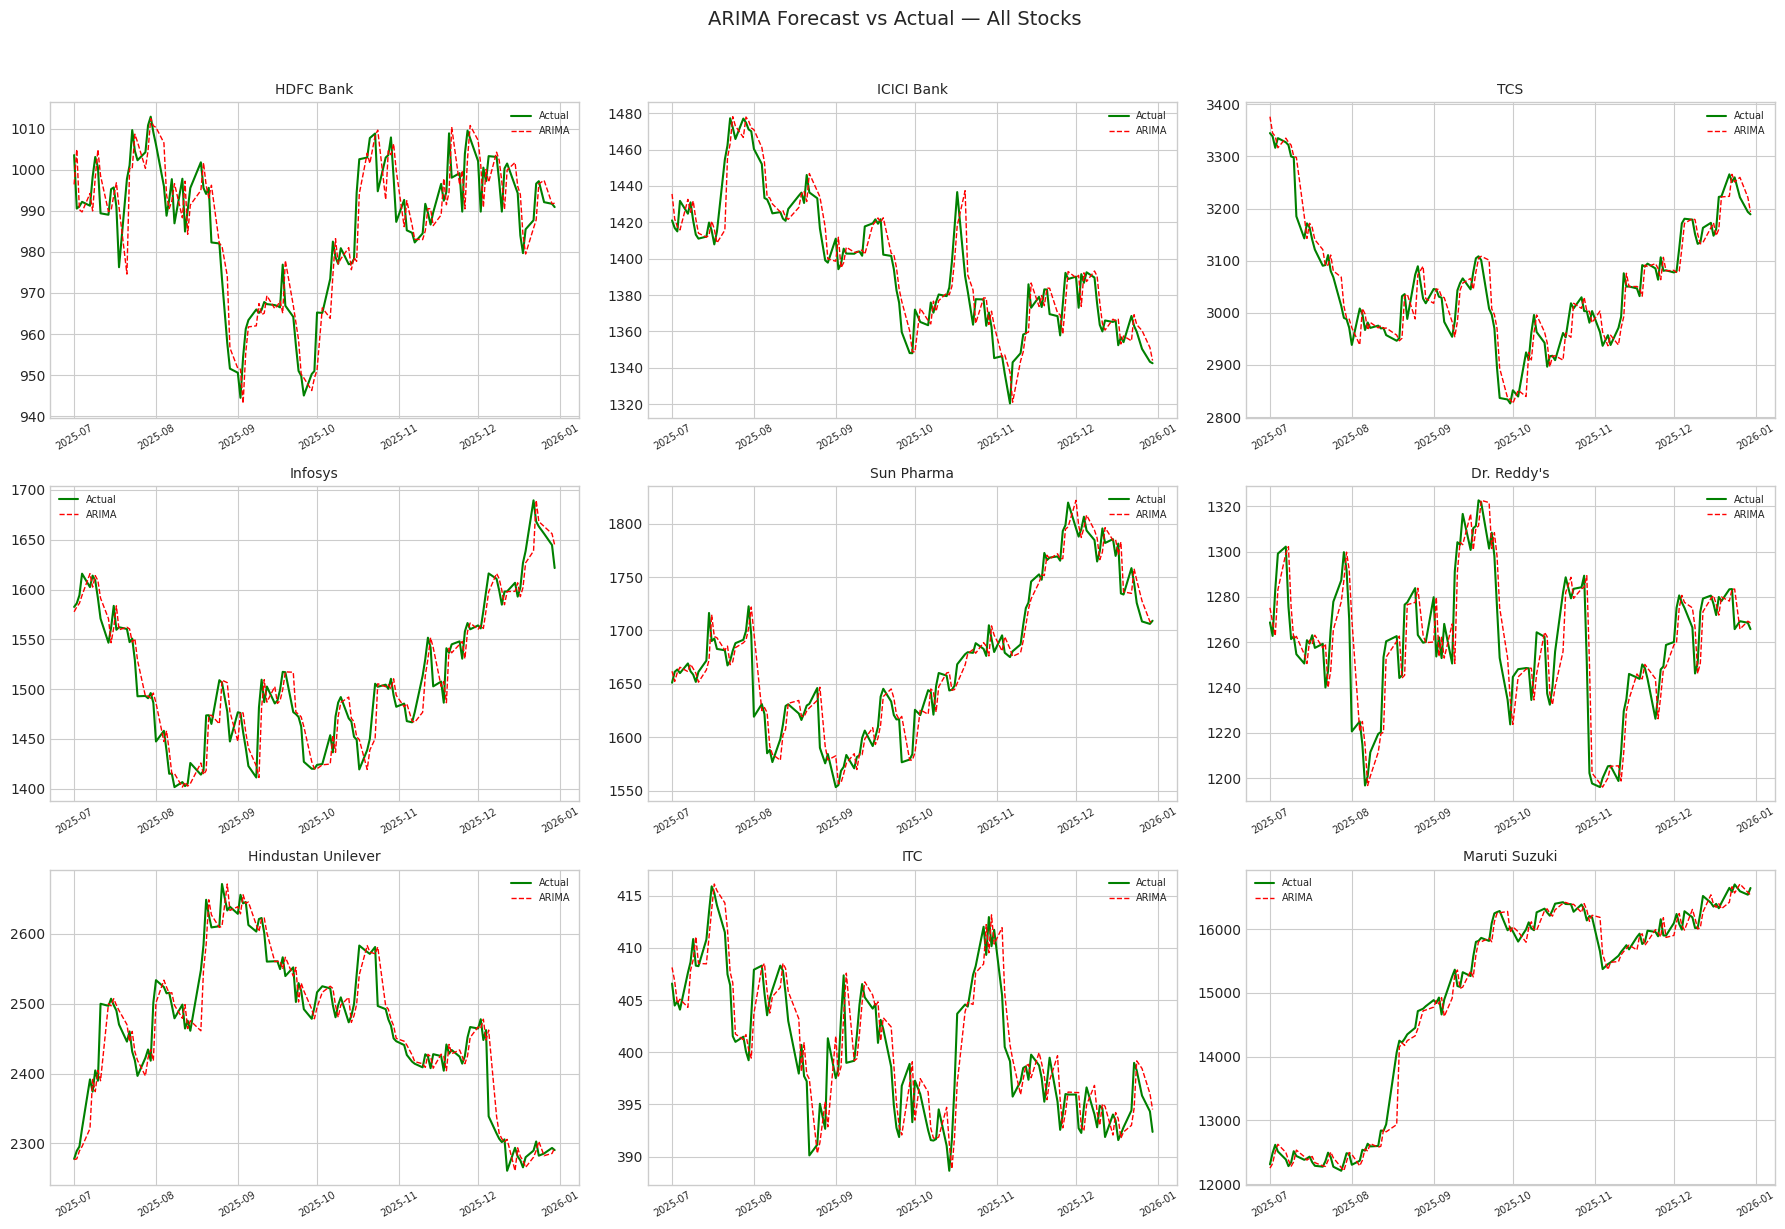

In [22]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (ticker, pred) in enumerate(all_preds.items()):
    if i >= 9:
        break
    ax = axes[i]
    actual = processed[ticker]["test"]
    ax.plot(actual, label="Actual", color="green", linewidth=1.5)
    ax.plot(pred, label="ARIMA", color="red", linewidth=1, linestyle="--")
    ax.set_title(f"{STOCK_UNIVERSE.get(ticker, ticker)}", fontsize=10)
    ax.tick_params(axis="x", rotation=30, labelsize=7)
    ax.legend(fontsize=7)

plt.suptitle("ARIMA Forecast vs Actual — All Stocks", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

- Auto ARIMA selected optimal (p,d,q) via AIC minimisation
- Residual diagnostics confirm white noise (Ljung-Box p > 0.05)
- Walk-forward evaluation gives realistic out-of-sample metrics
- Confidence intervals provided for future forecasts
- Results saved to `results/forecasts/`